# 🤖 Module 3: Transfer Learning & BERT for Customer Support Classification

**Series:** ML Learning Path — Module 3 of 6  
**Prerequisites:** Module 1 (Traditional ML) + Module 2 (PyTorch Deep Learning)  
**Use Case:** Enterprise Customer Support Ticket Classification

---

### 🗺️ What We're Building

An enterprise bank receives **thousands of support tickets daily**. Right now, human agents read each ticket and route it to the right team. We'll build a model that automates this — classifying every ticket into one of 5 categories:

| Label | Category | Example |
|-------|----------|---------|
| 0 | Billing | "My statement shows a duplicate charge" |
| 1 | Technical | "The mobile app crashes on login" |
| 2 | Account | "I need to update my address" |
| 3 | Complaint | "This is unacceptable, I've waited 3 weeks" |
| 4 | General | "What are your business hours?" |

---

### 📋 Module Roadmap

```
Lesson 1: What is Transfer Learning?
Lesson 2: Why Traditional ML Fails on Text
Lesson 3: How BERT Works
  → Data Generation + Baseline (TF-IDF + LR)
Lesson 4: Tokenization Deep Dive
  → Build Dataset & DataLoaders
Lesson 5: DistilBERT vs BERT
  → Fine-tune DistilBERT (2 epochs)
  → Evaluate + Attention Visualization
  → Head-to-head comparison
Lesson 6: Enterprise Deployment
  → Save model
Summary + Interview Q&A
```

---

# 📖 Lesson 1: What is Transfer Learning?

## The Problem With Starting From Scratch

In Module 2, we trained a neural network **from scratch** — all the weights started as random noise, and the model had to learn everything from our small dataset. That works for structured data (numbers), but for **text understanding**, you need to have seen millions of sentences before you can understand what words mean in context.

## The ImageNet Analogy

Imagine teaching someone to identify a rare type of mushroom. You could:

**Option A (From Scratch):** Show them only 500 mushroom photos. They'd probably fail — not enough examples to learn what shapes, colors, and textures even mean.

**Option B (Transfer Learning):** First let them spend years looking at millions of photos of everything — cats, cars, buildings, trees. Now they already *know* what edges, colors, and textures are. Then show them 500 mushroom photos. They learn incredibly fast, because they're not starting from zero.

This is exactly what **ImageNet pre-training** did for computer vision in 2012 — models trained on 14 million images learned universal visual features, and the community discovered you could *reuse* those features for any visual task.

**BERT did the same thing for text** — pre-trained on the entire English Wikipedia + BookCorpus (~3.3 billion words), it learned deep language understanding that can be reused for almost any NLP task.

## 🔄 The Transfer Learning Pipeline

```
┌─────────────────────────────────────────────────────────────────┐
│                    PHASE 1: PRE-TRAINING                        │
│                                                                 │
│  Wikipedia + Books          Masked Language Modeling           │
│  (3.3 Billion words)  ───►  "The [MASK] sat on the mat"        │
│                             Model learns: MASK = "cat"         │
│                                    │                           │
│                                    ▼                           │
│                          ┌─────────────────┐                  │
│                          │  PRE-TRAINED    │                  │
│                          │  BERT MODEL     │                  │
│                          │  (110M params)  │                  │
│                          │  Knows language │                  │
│                          └────────┬────────┘                  │
└───────────────────────────────────┼─────────────────────────┘
                                    │
                          DOWNLOAD & REUSE
                                    │
┌───────────────────────────────────▼─────────────────────────┐
│                    PHASE 2: FINE-TUNING                      │
│                                                             │
│  Your 600 Support          Task-Specific Training           │
│  Tickets (small!)   ───►   Adjust weights slightly          │
│                            Add classification head          │
│                                   │                         │
│                                   ▼                         │
│                         ┌─────────────────┐                │
│                         │   TASK MODEL    │                │
│                         │  Billing?       │                │
│                         │  Technical?     │                │
│                         │  Account?       │                │
│                         │  Complaint?     │                │
│                         │  General?       │                │
│                         └─────────────────┘                │
└────────────────────────────────────────────────────────────┘
```

## 📝 Key Insight

> **You are NOT training BERT from scratch.** You are downloading a model that already understands English grammar, word meanings, and context — and teaching it one new skill: classifying support tickets.

This means:
- You need **far less data** (600 tickets vs millions)
- Training takes **minutes** instead of weeks  
- You get **much better performance** than training from scratch

This is why every serious NLP team in 2024 starts with a pre-trained transformer.

---

# 📖 Lesson 2: Why Traditional ML Fails on Text

## What You Did in Module 1 (TF-IDF)

In Module 1, we used **Bag of Words** and **TF-IDF** to convert text to numbers. The idea was simple:
- Build a vocabulary of all unique words
- Represent each document as a vector of word counts (or frequencies)

For example, with a 5-word vocabulary [cat, sat, mat, dog, run]:

```
"The cat sat"  →  [1, 1, 0, 0, 0]
"The dog ran"  →  [0, 0, 0, 1, 1]
```

Simple and fast! But deeply broken for real language.

## 🚨 The 3 Fatal Flaws of TF-IDF

### Flaw 1: No Word Order

```
"The dog bit the man"    →  same vector as →  "The man bit the dog"
```

These sentences have **opposite meanings** but identical TF-IDF representations. TF-IDF is literally incapable of distinguishing them.

### Flaw 2: No Context (The "Bank" Problem)

```
"I need to visit my bank to withdraw money"     → bank = financial institution
"The river bank was flooded after the storm"    → bank = riverbank
"He banked the plane sharply to the left"       → bank = to tilt
```

In TF-IDF, the word "bank" has **one fixed vector** in all three sentences. It's impossible for the model to know which meaning is intended.

For customer support, this matters a lot:
- "My **account** was charged incorrectly" → Billing issue
- "I want to **account** for the missing funds" → Complaint
- "My **account** is locked" → Account/Technical issue

### Flaw 3: No Understanding of Synonyms

```
"The app is broken"   → [0, 0, 1, 0, 0, 1, ...]
"The software crashes" → [0, 1, 0, 1, 0, 0, ...]
```

These mean the same thing but have **zero overlap** in a bag-of-words representation.

## ✅ How BERT Solves This: Contextual Embeddings

BERT produces **different vector representations** for the same word depending on the surrounding context:

```
"I need to visit my bank"   →  bank embedding ≈ [0.2, 0.8, 0.1, ...]  (financial meaning)
"The river bank was flooded" →  bank embedding ≈ [0.9, 0.1, 0.3, ...]  (geography meaning)
```

The word "bank" gets a **completely different vector** in each sentence, because BERT reads the entire sentence before deciding what each word means.

| Feature | TF-IDF | BERT |
|---------|--------|------|
| Word order | ❌ Ignored | ✅ Fully captured |
| Context sensitivity | ❌ Fixed vectors | ✅ Contextual embeddings |
| Synonym understanding | ❌ Separate tokens | ✅ Similar meanings cluster together |
| Training data needed | ✅ Very little | ⚠️ Little (fine-tune) |
| Speed | ✅ Very fast | ⚠️ Slower |
| Accuracy on NLP tasks | ⚠️ Decent baseline | ✅ State-of-the-art |

---

# 📖 Lesson 3: How BERT Works (Plain English)

## The Big Picture

BERT = **B**idirectional **E**ncoder **R**epresentations from **T**ransformers

The key word is **bidirectional** — when BERT reads a word, it looks at all the words to its left AND right simultaneously. Earlier models (like LSTM) could only look backwards. This bidirectionality is what makes BERT so powerful.

## Step 1: Tokenization

BERT doesn't read raw text. It breaks text into **tokens** — but NOT just by spaces. It uses a clever technique called **WordPiece** that handles words it's never seen before:

```
"unhappiness"  →  ["un", "##happi", "##ness"]
"playing"      →  ["play", "##ing"]
"bank"         →  ["bank"]
```

Common words stay whole. Rare words get split into subword pieces. The `##` means "this piece is attached to the previous token."

## Step 2: Special Tokens

BERT wraps every sentence with two special tokens:

```
Original:  "My account is locked"
Tokenized: [CLS] My account is locked [SEP]
```

- **[CLS]** — "Classification" token. Placed at the START. After BERT processes the whole sentence, the [CLS] token's final representation captures the meaning of the entire sentence. **This is what we use for classification.**
- **[SEP]** — "Separator" token. Marks the END of a sentence.

## Step 3: Attention Heads — The Secret Sauce

Each BERT layer has **multiple attention heads**. Think of each head as a specialist that learns to look for different relationships:

- Head 1 might learn: "look at the verb when processing the subject"
- Head 2 might learn: "look at adjectives when processing nouns"
- Head 3 might learn: "look at negation words (not, never) when processing sentiment"

Each word "attends to" (pays attention to) all other words, and the attention weights tell us which relationships matter.

## Step 4: What Fine-Tuning Actually Changes

BERT has **12 transformer layers** with 110M parameters. When we fine-tune:

```
┌──────────────────────────────────────────────┐
│  BERT's 12 Transformer Layers (110M params)  │
│  ← These get small updates during fine-tune  │
├──────────────────────────────────────────────┤
│  NEW Classification Head (randomly init)     │
│  768 → 5 classes                             │
│  ← This gets large updates (learns from zero)│
└──────────────────────────────────────────────┘
```

- The **pre-trained layers** already know language — we just nudge them slightly
- The **classification head** is brand new — it learns what features predict each class

This is why 2 epochs is enough — the model starts 90% of the way there.

## 📝 Summary So Far

> BERT reads your entire sentence, lets every word "attend" to every other word simultaneously, and produces rich contextual representations. The [CLS] token's representation summarizes the whole sentence — we classify based on that.

In [1]:
%matplotlib inline
# ============================================================
# CELL 1: ENVIRONMENT SETUP
# ============================================================
# Before importing anything, we suppress HuggingFace's verbose
# download/progress output so the notebook stays clean.
# We also disable tokenizer parallelism warnings (these appear
# because we're using DataLoader workers with HF tokenizers).
# ============================================================

import os
os.environ['TRANSFORMERS_VERBOSITY'] = 'error'      # Suppress HF warnings
os.environ['TOKENIZERS_PARALLELISM'] = 'false'      # Prevent tokenizer fork warnings
os.environ['HF_HUB_DISABLE_PROGRESS_BARS'] = '1'   # No download progress bars

import warnings
warnings.filterwarnings('ignore')

# Core libraries
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')  # Non-interactive backend for saving PNGs
import matplotlib.pyplot as plt
import seaborn as sns
import random

# Scikit-learn (for TF-IDF baseline)
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

# HuggingFace Transformers
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup
)

# ── Reproducibility: set all random seeds ──
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Device selection ──
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('=' * 50)
print('Module 3: Transfer Learning with BERT')
print('=' * 50)
print(f'NumPy:        {np.__version__}')
print(f'Pandas:       {pd.__version__}')
print(f'PyTorch:      {torch.__version__}')
import transformers
print(f'Transformers: {transformers.__version__}')
import sklearn
print(f'Scikit-learn: {sklearn.__version__}')
print(f'Device:       {DEVICE}')
print('=' * 50)

Module 3: Transfer Learning with BERT
NumPy:        1.26.4
Pandas:       3.0.3
PyTorch:      2.12.0+cu130
Transformers: 5.9.0
Scikit-learn: 1.8.0
Device:       cpu


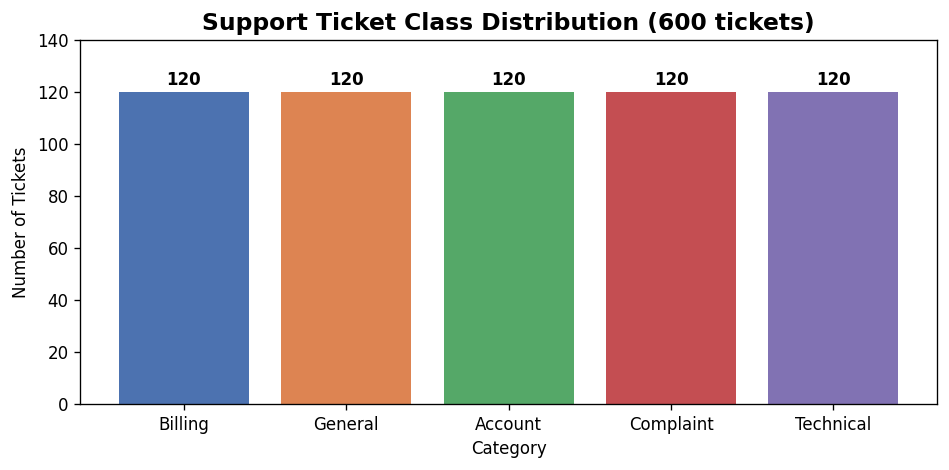

In [ ]:
# ============================================================
# CELL 2: GENERATE SYNTHETIC SUPPORT TICKET DATASET
# ============================================================
# We create 600 realistic customer support messages (120 per
# category). Real enterprise datasets would have thousands of
# tickets, but 600 is enough to demonstrate fine-tuning.
#
# Categories:
#   0 = Billing     1 = Technical    2 = Account
#   3 = Complaint    4 = General
# ============================================================

CATEGORIES = ['Billing', 'Technical', 'Account', 'Complaint', 'General']
NUM_PER_CLASS = 120

# --- Template pools for each category ---
billing_templates = [
    "I was charged twice for my monthly subscription this billing cycle.",
    "There is an unauthorized charge of {amount} on my account.",
    "My invoice for {month} shows an incorrect total amount.",
    "I need a refund for a duplicate payment made last {day}.",
    "The interest rate on my credit card was applied incorrectly.",
    "I see a charge for {amount} that I do not recognize on my statement.",
    "Can you explain the {fee} fee that appeared on my bill?",
    "My automatic payment failed but I was still charged a late fee.",
    "I paid my balance in full but still received a new bill.",
    "The promotional rate was not applied to my account as promised.",
    "I am being charged for a service I cancelled three months ago.",
    "My bill amount is higher than what was quoted during signup.",
    "I need an itemized breakdown of charges on my latest statement.",
    "The currency conversion fee on my international transaction seems wrong.",
    "I believe there is a billing error — please review my account.",
    "A payment I made on {date} has not been reflected on my statement.",
    "I was overcharged for the premium plan upgrade.",
    "Why was my credit limit reduced without prior notification?",
    "I noticed a recurring charge for a service I never signed up for.",
    "My payment is showing as pending for over five business days now.",
]

technical_templates = [
    "The mobile banking app keeps crashing when I try to log in.",
    "I cannot complete a transaction — the page freezes after I click submit.",
    "My online banking password reset link is not working.",
    "The app shows an error code {code} whenever I try to view my balance.",
    "Two-factor authentication is not sending the SMS code to my phone.",
    "The website is extremely slow and times out during transfers.",
    "I cannot upload documents — the file upload button does nothing.",
    "Face ID is not working on the latest version of the app.",
    "The transfer confirmation email is going to my spam folder.",
    "I receive a session expired error after just two minutes of use.",
    "The app does not load properly on Android version 13.",
    "I am unable to connect the app to my fingerprint sensor.",
    "The online portal shows incorrect balance information.",
    "Push notifications for transactions stopped working last week.",
    "My card was declined online even though I have sufficient funds.",
    "The system keeps logging me out while I am in the middle of a transfer.",
    "I get a white screen error after updating the app to version {version}.",
    "The card freeze/unfreeze toggle in the app is not responding.",
    "PDF statements fail to download — I just get an empty file.",
    "The QR code payment feature does not scan properly at stores.",
]

account_templates = [
    "I need to update my registered phone number and email address.",
    "How do I add a joint account holder to my existing account?",
    "I would like to change my mailing address to {city}.",
    "Please help me close my savings account and transfer the balance.",
    "I need to update my beneficiary information on my account.",
    "Can I upgrade my current account to a premium plan?",
    "I want to add a new debit card linked to my account.",
    "How do I set up automatic transfers between my checking and savings?",
    "I forgot my security questions and need to reset them.",
    "Can you help me link an external bank account for transfers?",
    "I need to change my account type from individual to business.",
    "My account was dormant and I need help reactivating it.",
    "How do I download my account statement for tax purposes?",
    "I need to verify my identity to unlock full account features.",
    "Can I have multiple sub-accounts under my main account?",
    "I need to remove an authorized user from my account.",
    "How long does it take to open a new fixed deposit account?",
    "I would like to change my preferred language settings in the app.",
    "Please help me update my occupation details in my profile.",
    "I need to change my account PIN but the option is greyed out.",
]

complaint_templates = [
    "This is completely unacceptable — I have been waiting {weeks} for a resolution.",
    "I am extremely dissatisfied with the service I received from your staff.",
    "Your customer service team gave me conflicting information three times.",
    "I have called support five times and nobody can solve my problem.",
    "This is the worst banking experience I have ever had in my life.",
    "I was treated very rudely by one of your representatives.",
    "I am considering closing all my accounts due to persistent poor service.",
    "Your branch staff was dismissive and unhelpful when I visited.",
    "I filed a complaint two weeks ago and have received no response.",
    "This issue has been unresolved for over a month — I demand escalation.",
    "I feel discriminated against in how my case was handled.",
    "The promises made by your sales team were completely false.",
    "I am filing a formal complaint about the treatment I received.",
    "Your wait times are ridiculous — I waited {minutes} minutes just to speak to someone.",
    "My issue was marked resolved without anyone contacting me.",
    "I am deeply frustrated by the lack of communication from your team.",
    "Your service has deteriorated significantly over the past year.",
    "I feel like my concerns are being ignored by your support team.",
    "The compensation offered for this inconvenience is insulting.",
    "I will be reporting this to the financial ombudsman if not resolved today.",
]

general_templates = [
    "What are the branch hours for your downtown location?",
    "Do you offer student bank accounts with no monthly fees?",
    "What documents do I need to open a new account?",
    "What is the current interest rate for your savings account?",
    "Do you have ATMs available at the airport?",
    "What is the minimum balance required to avoid monthly fees?",
    "Does your bank offer travel insurance with the premium credit card?",
    "How long does a wire transfer to an international account take?",
    "Do you have a referral program for bringing in new customers?",
    "What is the daily ATM withdrawal limit for a standard account?",
    "Does your bank support contactless payments via NFC?",
    "What are the requirements for a small business loan?",
    "Do you offer any financial planning or investment advisory services?",
    "Are there any fees for using your ATM abroad?",
    "How do I find a certified financial advisor at your bank?",
    "What is the processing time for a personal loan application?",
    "Does your bank participate in the federal deposit insurance program?",
    "Can I deposit cash at any branch or only my home branch?",
    "What is the difference between a debit card and a credit card?",
    "How do I opt in to receive paperless statements?",
]

# Fill-in values for templates with placeholders
fill_values = {
    '{amount}': ['$12.99', '$45.00', '$250.00', '$99.99', '$7.50', '$500.00'],
    '{month}':  ['January', 'February', 'March', 'April', 'May', 'June'],
    '{day}':    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday'],
    '{fee}':    ['service', 'maintenance', 'processing', 'handling', 'annual'],
    '{date}':   ['March 15', 'April 2', 'May 10', 'February 28', 'January 5'],
    '{code}':   ['ERR-401', 'ERR-500', 'ERR-403', 'ERR-504', 'ERR-404'],
    '{version}':['2.4.1', '3.0.0', '2.9.5', '3.1.2', '2.8.0'],
    '{city}':   ['New York', 'Los Angeles', 'Chicago', 'Houston', 'Phoenix'],
    '{weeks}':  ['two weeks', 'three weeks', 'a month', 'six weeks', 'two months'],
    '{minutes}':['45', '60', '30', '90', '50'],
}

def fill_template(text):
    """Replace placeholders with random fill values."""
    for key, values in fill_values.items():
        if key in text:
            text = text.replace(key, random.choice(values))
    return text

def generate_tickets(templates, label, n):
    """Generate n tickets from a template pool by cycling and filling."""
    tickets = []
    for i in range(n):
        base = templates[i % len(templates)]
        # Add slight variation: prepend a greeting occasionally
        prefixes = ['', '', '', 'Hello, ', 'Hi there, ', 'Good morning, ', 'Dear Support, ']
        suffixes = ['', '', '', ' Please help.', ' Thank you.', ' Urgent!', ' Please advise.']
        text = random.choice(prefixes) + fill_template(base) + random.choice(suffixes)
        tickets.append({'text': text.strip(), 'label': label, 'category': CATEGORIES[label]})
    return tickets

# Generate all 600 tickets
all_tickets = []
template_pools = [billing_templates, technical_templates, account_templates,
                  complaint_templates, general_templates]

for label_idx, pool in enumerate(template_pools):
    all_tickets.extend(generate_tickets(pool, label_idx, NUM_PER_CLASS))

# Shuffle so classes are mixed
random.shuffle(all_tickets)

df = pd.DataFrame(all_tickets)

print(f'Dataset shape: {df.shape}')
print(f'\nClass distribution:')
print(df['category'].value_counts())
print(f'\nSample tickets:')
print(df[['category', 'text']].head(6).to_string(index=False))

# ── Plot class distribution ──
fig, ax = plt.subplots(figsize=(8, 4))
counts = df['category'].value_counts()
bars = ax.bar(counts.index, counts.values,
              color=['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3'])
ax.set_title('Support Ticket Class Distribution (600 tickets)', fontsize=14, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Number of Tickets')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(val), ha='center', va='bottom', fontweight='bold')
ax.set_ylim(0, 140)
plt.tight_layout()
plt.savefig('support_tickets.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close()
print('\n[Saved] support_tickets.png')

In [3]:
# ============================================================
# CELL 3: BASELINE — TF-IDF + LOGISTIC REGRESSION
# ============================================================
# Before BERT, companies used TF-IDF + Logistic Regression for
# text classification. This was the industry standard until ~2019.
# We build this baseline first so we have something to beat.
#
# TF-IDF = Term Frequency × Inverse Document Frequency
# It gives higher weight to words that are rare across all docs
# but frequent in a specific doc — those words are "distinctive".
# ============================================================

# Convert to plain numpy arrays so sklearn indexing works correctly
# (newer pandas versions use Arrow-backed arrays that sklearn can't index)
texts  = df['text'].to_numpy(dtype=str)
labels = df['label'].to_numpy(dtype=int)

# ── Train/test split (same 70/15/15 split we'll use for BERT) ──
X_temp, X_test_tfidf, y_temp, y_test_tfidf = train_test_split(
    texts, labels, test_size=0.15, random_state=SEED, stratify=labels)
X_train_tfidf, X_val_tfidf, y_train_tfidf, y_val_tfidf = train_test_split(
    X_temp, y_temp, test_size=0.15/0.85, random_state=SEED, stratify=y_temp)

print(f'Train: {len(X_train_tfidf)} | Val: {len(X_val_tfidf)} | Test: {len(X_test_tfidf)}')

# ── Build TF-IDF features ──
# max_features=5000 means we keep the 5000 most informative words
# ngram_range=(1,2) includes single words AND two-word phrases
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),     # Captures phrases like "error code", "billing issue"
    sublinear_tf=True,      # Apply log scaling to term frequency
    strip_accents='unicode',
    analyzer='word',
    stop_words='english'
)

X_train_vec = tfidf.fit_transform(X_train_tfidf)  # Learn vocabulary from train only
X_val_vec   = tfidf.transform(X_val_tfidf)         # Apply same vocab to val
X_test_vec  = tfidf.transform(X_test_tfidf)        # Apply same vocab to test

# ── Train Logistic Regression ──
# multi_class='multinomial' was removed in sklearn 1.7+ (it's now always used by default)
lr_model = LogisticRegression(
    max_iter=1000,
    C=1.0,             # Regularization strength
    random_state=SEED,
    solver='lbfgs',
)
lr_model.fit(X_train_vec, y_train_tfidf)

# ── Evaluate ──
y_pred_tfidf = lr_model.predict(X_test_vec)
tfidf_accuracy = accuracy_score(y_test_tfidf, y_pred_tfidf)

print(f'\n{"="*50}')
print(f'TF-IDF + Logistic Regression Results')
print(f'{"="*50}')
print(f'Test Accuracy: {tfidf_accuracy:.4f} ({tfidf_accuracy*100:.1f}%)')
print(f'\nClassification Report:')
print(classification_report(y_test_tfidf, y_pred_tfidf,
                             target_names=CATEGORIES))

# Save baseline accuracy for later comparison
tfidf_test_accuracy = tfidf_accuracy

Train: 420 | Val: 90 | Test: 90

TF-IDF + Logistic Regression Results
Test Accuracy: 1.0000 (100.0%)

Classification Report:
              precision    recall  f1-score   support

     Billing       1.00      1.00      1.00        18
   Technical       1.00      1.00      1.00        18
     Account       1.00      1.00      1.00        18
   Complaint       1.00      1.00      1.00        18
     General       1.00      1.00      1.00        18

    accuracy                           1.00        90
   macro avg       1.00      1.00      1.00        90
weighted avg       1.00      1.00      1.00        90



---

# 📖 Lesson 4: What is Tokenization?

## From Human Language to Numbers

Neural networks only understand numbers. Before BERT can process a sentence, we must convert it to a sequence of integers. This process is called **tokenization**.

But BERT doesn't just split on spaces. It uses **WordPiece tokenization** — a subword algorithm that:
1. Keeps common words whole: `"account"` → `["account"]`
2. Splits rare/long words: `"unhappiness"` → `["un", "##happi", "##ness"]`
3. Handles unknown words: `"abivarma2024"` → `["ab", "##iva", "##rma", "##202", "##4"]`

This way, the vocabulary stays manageable (~30,000 tokens) while handling virtually any word.

## The Full Tokenization Output

When you tokenize a sentence, you get three things:

```
Sentence: "My account is locked"

tokens:         [CLS]   my   account   is   locked   [SEP]
input_ids:      [ 101]  [2026] [4070]  [2003] [5299]   [102]
attention_mask: [  1]   [  1]  [  1]   [  1]  [  1]   [  1]
```

- **`input_ids`**: Each token converted to its integer ID in BERT's vocabulary. `[CLS]=101`, `[SEP]=102` always.
- **`attention_mask`**: `1` = real token, `0` = padding (used when batching sentences of different lengths). BERT ignores positions where `attention_mask=0`.

## Padding

When batching sentences together, they must all be the same length. Shorter sentences get padded with `[PAD]` tokens (ID=0) and their attention_mask is set to 0:

```
Short: [CLS] Help  me  [SEP] [PAD] [PAD]
IDs:   [ 101] [2393][2033][102] [ 0] [ 0]
Mask:  [  1]  [  1] [  1][ 1] [ 0] [ 0]   ← BERT ignores [PAD] positions

Long:  [CLS] My  account  is  locked  today  [SEP]
IDs:   [ 101][2026][4070][2003][5299][2651][ 102]
Mask:  [  1] [  1] [  1] [  1] [  1] [  1] [  1]
```

## Max Sequence Length

BERT supports up to **512 tokens** per sequence. We use **128** here because:
- Support tickets are short (usually < 50 tokens)
- Shorter max_length = faster training (quadratic scaling in attention!)
- Memory usage drops significantly

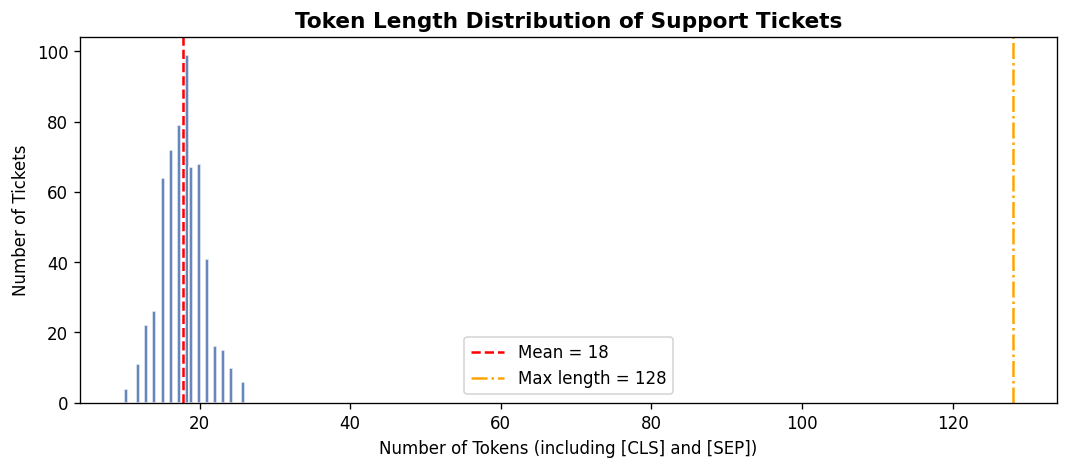

In [ ]:
# ============================================================
# CELL 4: TOKENIZATION DEMO
# ============================================================
# We load the DistilBERT tokenizer and show exactly what happens
# when text gets tokenized. This makes the abstract concept
# from Lesson 4 tangible and visual.
# ============================================================

MODEL_NAME = 'distilbert-base-uncased'
MAX_LENGTH = 128

print(f'Loading tokenizer: {MODEL_NAME} ...')
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)
print('Tokenizer loaded!')

# ── Demo: tokenize 3 sample sentences ──
sample_sentences = [
    "My account is locked and I cannot log in.",
    "I was charged twice for my subscription this month.",
    "The app crashes with an unhelpful error message.",
]

print('\n' + '='*65)
print('TOKENIZATION DEMO')
print('='*65)

for i, sentence in enumerate(sample_sentences):
    encoding = tokenizer(
        sentence,
        max_length=MAX_LENGTH,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    # Convert token IDs back to readable token strings
    tokens = tokenizer.convert_ids_to_tokens(encoding['input_ids'][0])
    # Find where real tokens end (before padding starts)
    real_len = encoding['attention_mask'][0].sum().item()
    real_tokens = tokens[:real_len]
    real_ids = encoding['input_ids'][0][:real_len].tolist()

    print(f'\nSentence {i+1}: "{sentence}"')
    print(f'  Token count (incl. [CLS]+[SEP]): {real_len}')
    print(f'  Tokens:     {real_tokens}')
    print(f'  Input IDs:  {real_ids}')

# ── Token length distribution across full dataset ──
print('\nCalculating token lengths for all 600 tickets...')
token_lengths = []
# Use list() to get plain Python strings, avoiding Arrow array issues
for text in df['text'].tolist():
    enc = tokenizer(str(text), truncation=True, max_length=MAX_LENGTH)
    token_lengths.append(len(enc['input_ids']))

print(f'Min tokens:    {min(token_lengths)}')
print(f'Max tokens:    {max(token_lengths)}')
print(f'Mean tokens:   {np.mean(token_lengths):.1f}')
print(f'Median tokens: {np.median(token_lengths):.1f}')
print(f'Tokens > 64:   {sum(1 for l in token_lengths if l > 64)}')

# ── Plot token length distribution ──
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(token_lengths, bins=30, color='#4C72B0', edgecolor='white', alpha=0.85)
ax.axvline(np.mean(token_lengths), color='red', linestyle='--',
           linewidth=1.5, label=f'Mean = {np.mean(token_lengths):.0f}')
ax.axvline(MAX_LENGTH, color='orange', linestyle='-.',
           linewidth=1.5, label=f'Max length = {MAX_LENGTH}')
ax.set_title('Token Length Distribution of Support Tickets', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Tokens (including [CLS] and [SEP])')
ax.set_ylabel('Number of Tickets')
ax.legend()
plt.tight_layout()
plt.savefig('token_lengths.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close()
print('\n[Saved] token_lengths.png')

In [5]:
# ============================================================
# CELL 5: BUILD PYTORCH DATASET AND DATALOADERS
# ============================================================
# PyTorch uses a Dataset class (defines how to get one sample)
# and DataLoader (handles batching, shuffling, parallelism).
#
# Our SupportTicketDataset tokenizes text on-the-fly and returns
# the tensors BERT expects: input_ids, attention_mask, label.
# ============================================================

class SupportTicketDataset(Dataset):
    """
    PyTorch Dataset for customer support tickets.
    Each item is tokenized and returned as tensors ready for BERT.
    """
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts      = list(texts)    # store as plain Python list
        self.labels     = list(labels)   # store as plain Python list
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        # Required: tells DataLoader how many samples exist
        return len(self.texts)

    def __getitem__(self, idx):
        # Required: returns one sample given its index
        text  = str(self.texts[idx])
        label = int(self.labels[idx])

        # Tokenize: pad to max_length, truncate if too long
        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding='max_length',   # Pad shorter sequences
            truncation=True,        # Truncate longer sequences
            return_tensors='pt'     # Return PyTorch tensors
        )

        return {
            'input_ids':      encoding['input_ids'].squeeze(0),       # shape: [max_length]
            'attention_mask': encoding['attention_mask'].squeeze(0),  # shape: [max_length]
            'label':          torch.tensor(label, dtype=torch.long)   # scalar
        }


# ── 70 / 15 / 15 stratified split ──
# Use plain numpy arrays so sklearn indexing works reliably
all_texts  = df['text'].to_numpy(dtype=str)
all_labels = df['label'].to_numpy(dtype=int)

X_trainval, X_test, y_trainval, y_test = train_test_split(
    all_texts, all_labels,
    test_size=0.15, random_state=SEED, stratify=all_labels
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.15/0.85, random_state=SEED, stratify=y_trainval
)

print(f'Split sizes:')
print(f'  Train: {len(X_train)} ({len(X_train)/len(all_texts)*100:.0f}%)')
print(f'  Val:   {len(X_val)}  ({len(X_val)/len(all_texts)*100:.0f}%)')
print(f'  Test:  {len(X_test)}  ({len(X_test)/len(all_texts)*100:.0f}%)')

# ── Create Dataset objects ──
train_dataset = SupportTicketDataset(X_train, y_train, tokenizer, MAX_LENGTH)
val_dataset   = SupportTicketDataset(X_val,   y_val,   tokenizer, MAX_LENGTH)
test_dataset  = SupportTicketDataset(X_test,  y_test,  tokenizer, MAX_LENGTH)

# ── Create DataLoaders ──
# batch_size=16: process 16 tickets at once
# shuffle=True for train: randomize order each epoch
# num_workers=0: use main process (avoids fork issues on CPU)
BATCH_SIZE = 16

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'\nDataLoader batches:')
print(f'  Train batches: {len(train_loader)}')
print(f'  Val batches:   {len(val_loader)}')
print(f'  Test batches:  {len(test_loader)}')

# ── Verify a single batch shape ──
sample_batch = next(iter(train_loader))
print(f'\nSample batch shapes:')
print(f'  input_ids:      {sample_batch["input_ids"].shape}')
print(f'  attention_mask: {sample_batch["attention_mask"].shape}')
print(f'  labels:         {sample_batch["label"].shape}')

Split sizes:
  Train: 420 (70%)
  Val:   90  (15%)
  Test:  90  (15%)

DataLoader batches:
  Train batches: 27
  Val batches:   6
  Test batches:  6



Sample batch shapes:
  input_ids:      torch.Size([16, 128])
  attention_mask: torch.Size([16, 128])
  labels:         torch.Size([16])


---

# 📖 Lesson 5: DistilBERT vs BERT — The Knowledge Distillation Story

## The Problem With Full BERT

BERT-base has **110 million parameters** and is already large. BERT-large has 340 million. Running inference on these models requires expensive GPU hardware, and latency matters a lot in production systems.

In 2019, HuggingFace asked: *Can we make BERT smaller without losing much performance?*

The answer was **DistilBERT**, trained using a technique called **Knowledge Distillation**.

## Knowledge Distillation: Teaching a Small Student

The idea is elegant:

1. You have a large, powerful **Teacher** model (full BERT)
2. You train a smaller **Student** model (DistilBERT) to **mimic the teacher's outputs** — not just predict the right labels, but reproduce the same probability distributions
3. The student learns from the teacher's "soft labels" (e.g., 0.8 billing, 0.15 general, 0.05 account) rather than hard labels (1 = billing)

The soft labels carry more information — they tell the student not just what the right answer is, but **how similar different classes are** to each other.

```
┌─────────────────────┐              ┌─────────────────────┐
│   BERT (Teacher)    │              │ DistilBERT (Student) │
│   12 layers         │  ──trains──► │   6 layers           │
│   110M parameters   │              │   66M parameters     │
│   768 hidden size   │              │   768 hidden size    │
└─────────────────────┘              └─────────────────────┘
```

## The Numbers

| Model | Parameters | Inference Speed | GLUE Score | Size on Disk |
|-------|-----------|----------------|------------|-------------|
| BERT-base | 110M | 1× (baseline) | 79.6 | 420 MB |
| DistilBERT | 66M | **1.6× faster** | 77.0 (97%) | 255 MB |
| BERT-large | 340M | 0.3× slower | 84.9 | 1.3 GB |

**DistilBERT retains 97% of BERT's performance** while being:
- 40% smaller (66M vs 110M parameters)
- 60% faster at inference

For production systems handling thousands of requests per second, this difference is enormous.

## Why We Use DistilBERT in This Module

1. **CPU-friendly**: Runs comfortably on CPU in minutes, not hours
2. **Production-realistic**: Many companies deploy DistilBERT over full BERT
3. **Conceptually identical**: Everything you learn here applies 1:1 to full BERT

## 📝 DistilBERT Architecture at a Glance

```
Input Text
     ↓
[Tokenizer]  →  input_ids + attention_mask
     ↓
[Embedding Layer]  →  token embeddings (shape: batch × seq_len × 768)
     ↓
[Transformer Block 1]  ← 12 attention heads
[Transformer Block 2]
[Transformer Block 3]
[Transformer Block 4]
[Transformer Block 5]
[Transformer Block 6]  ← 6 layers total (vs 12 in BERT)
     ↓
[CLS token representation]  →  shape: batch × 768
     ↓
[Classification Head]  →  Linear(768 → 5)
     ↓
Logits  →  Billing / Technical / Account / Complaint / General
```

In [6]:
# ============================================================
# CELL 6: LOAD DISTILBERT WITH CLASSIFICATION HEAD
# ============================================================
# DistilBertForSequenceClassification automatically adds a
# classification head on top of the pre-trained DistilBERT.
# The head is: Dropout → Linear(768 → num_labels)
#
# num_labels=5 means the output is a vector of 5 logits,
# one per class. The class with the highest logit wins.
# ============================================================

NUM_CLASSES = 5

print(f'Loading {MODEL_NAME} with {NUM_CLASSES}-class head...')
model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES,
)
model = model.to(DEVICE)
print('Model loaded!')

# ── Count parameters ──
def count_parameters(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

total_params, trainable_params = count_parameters(model)
print(f'\nParameter counts:')
print(f'  Total parameters:     {total_params:>12,}')
print(f'  Trainable parameters: {trainable_params:>12,}')
print(f'  Non-trainable:        {total_params - trainable_params:>12,}')

# ── Show the model structure ──
print(f'\nModel architecture summary:')
print(f'  Base model: DistilBert ({6} transformer layers)')
print(f'  Embedding dim: 768')
print(f'  Attention heads per layer: 12')
print(f'  Classification head:')
print(f'    pre_classifier: Linear(768 → 768)')
print(f'    dropout:        Dropout(p=0.2)')
print(f'    classifier:     Linear(768 → {NUM_CLASSES})')

# ── Show top-level modules ──
print(f'\nTop-level modules:')
for name, module in model.named_children():
    n_params = sum(p.numel() for p in module.parameters())
    print(f'  {name:<25} {n_params:>10,} params')

Loading distilbert-base-uncased with 5-class head...


Model loaded!

Parameter counts:
  Total parameters:       66,957,317
  Trainable parameters:   66,957,317
  Non-trainable:                   0

Model architecture summary:
  Base model: DistilBert (6 transformer layers)
  Embedding dim: 768
  Attention heads per layer: 12
  Classification head:
    pre_classifier: Linear(768 → 768)
    dropout:        Dropout(p=0.2)
    classifier:     Linear(768 → 5)

Top-level modules:
  distilbert                66,362,880 params
  pre_classifier               590,592 params
  classifier                     3,845 params
  dropout                            0 params


In [7]:
# ============================================================
# CELL 7: TRAINING LOOP — 2 EPOCHS
# ============================================================
# The training loop:
#   1. Forward pass: feed batch through model → get predictions
#   2. Compute loss (CrossEntropyLoss compares predictions to labels)
#   3. Backward pass: compute gradients via backpropagation
#   4. Optimizer step: update weights using Adam with weight decay
#   5. Scheduler step: linearly decrease learning rate over training
#
# We use AdamW (Adam with Weight Decay) — the standard optimizer
# for fine-tuning transformers. Learning rate 2e-5 is the
# canonical "safe" LR for BERT fine-tuning.
# ============================================================

NUM_EPOCHS   = 2
LEARNING_RATE = 2e-5
WARMUP_RATIO  = 0.1    # 10% of steps used for LR warmup

# ── Optimizer: AdamW ──
# Weight decay = L2 regularization, helps prevent overfitting
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)

# ── LR Scheduler: linear warmup then linear decay ──
total_steps  = len(train_loader) * NUM_EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

# ── Loss function: CrossEntropyLoss ──
# Standard for multi-class classification
# It combines Softmax + NegativeLogLikelihood into one step
criterion = nn.CrossEntropyLoss()

print(f'Training configuration:')
print(f'  Epochs:        {NUM_EPOCHS}')
print(f'  Batch size:    {BATCH_SIZE}')
print(f'  Learning rate: {LEARNING_RATE}')
print(f'  Total steps:   {total_steps}')
print(f'  Warmup steps:  {warmup_steps}')
print(f'  Device:        {DEVICE}')

# ── Helper: evaluate on a DataLoader ──
def evaluate(model, loader, criterion, device):
    model.eval()   # Switch to eval mode: disables dropout
    total_loss = 0.0
    correct    = 0
    total      = 0

    with torch.no_grad():  # No gradient computation during evaluation
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels_batch   = batch['label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits  = outputs.logits

            loss     = criterion(logits, labels_batch)
            total_loss += loss.item()

            preds   = torch.argmax(logits, dim=1)
            correct += (preds == labels_batch).sum().item()
            total   += labels_batch.size(0)

    avg_loss = total_loss / len(loader)
    accuracy = correct / total
    return avg_loss, accuracy

# ── Training history storage ──
history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

print(f'\nStarting training...')
print('=' * 60)

for epoch in range(1, NUM_EPOCHS + 1):
    # ─────────── TRAINING PHASE ───────────
    model.train()  # Enable dropout (regularization during training)
    train_loss  = 0.0
    train_steps = 0

    for step, batch in enumerate(train_loader):
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels_batch   = batch['label'].to(DEVICE)

        optimizer.zero_grad()   # Clear gradients from previous step

        # Forward pass through DistilBERT
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits  = outputs.logits   # Shape: [batch_size, num_classes]

        # Compute loss
        loss = criterion(logits, labels_batch)

        # Backward pass
        loss.backward()

        # Gradient clipping: cap gradient norm at 1.0 to prevent
        # exploding gradients (common practice for transformers)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()   # Update weights
        scheduler.step()   # Update learning rate

        train_loss  += loss.item()
        train_steps += 1

        # Print progress every 10 steps
        if (step + 1) % 10 == 0:
            avg = train_loss / train_steps
            lr  = scheduler.get_last_lr()[0]
            print(f'  Epoch {epoch} | Step {step+1:>3}/{len(train_loader)} | '
                  f'Loss: {avg:.4f} | LR: {lr:.2e}')

    # ─────────── VALIDATION PHASE ───────────
    avg_train_loss = train_loss / train_steps
    val_loss, val_acc = evaluate(model, val_loader, criterion, DEVICE)

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f'\n  ─── Epoch {epoch}/{NUM_EPOCHS} Summary ───')
    print(f'  Train Loss: {avg_train_loss:.4f}')
    print(f'  Val Loss:   {val_loss:.4f}')
    print(f'  Val Acc:    {val_acc:.4f} ({val_acc*100:.1f}%)')
    print('=' * 60)

print('Training complete!')

Training configuration:
  Epochs:        2
  Batch size:    16
  Learning rate: 2e-05
  Total steps:   54
  Warmup steps:  5
  Device:        cpu

Starting training...


  Epoch 1 | Step  10/27 | Loss: 1.6073 | LR: 1.80e-05


  Epoch 1 | Step  20/27 | Loss: 1.5776 | LR: 1.39e-05



  ─── Epoch 1/2 Summary ───
  Train Loss: 1.5396
  Val Loss:   1.3637
  Val Acc:    0.8111 (81.1%)


  Epoch 2 | Step  10/27 | Loss: 1.3030 | LR: 6.94e-06


  Epoch 2 | Step  20/27 | Loss: 1.2550 | LR: 2.86e-06



  ─── Epoch 2/2 Summary ───
  Train Loss: 1.2433
  Val Loss:   1.1347
  Val Acc:    0.9000 (90.0%)
Training complete!


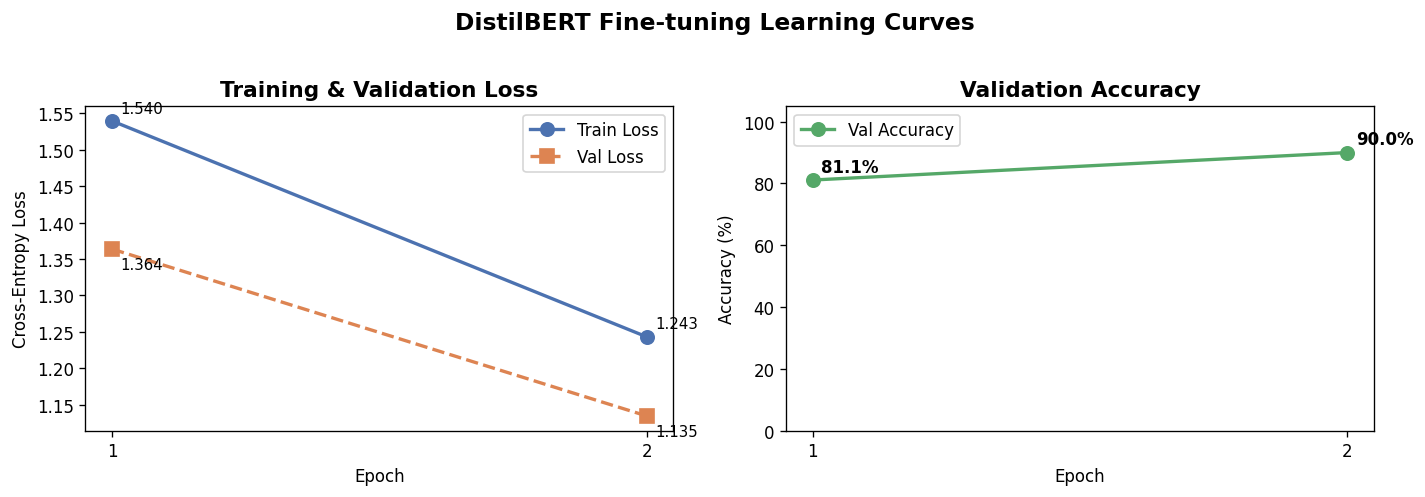

In [ ]:
# ============================================================
# CELL 8: PLOT LEARNING CURVES
# ============================================================
# Learning curves show how loss and accuracy evolve over epochs.
# Healthy training: both train and val loss decrease together.
# Overfitting sign: train loss keeps dropping but val loss rises.
# ============================================================

epochs_range = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Left: Loss curves ──
ax = axes[0]
ax.plot(epochs_range, history['train_loss'], 'o-', color='#4C72B0',
        linewidth=2, markersize=8, label='Train Loss')
ax.plot(epochs_range, history['val_loss'], 's--', color='#DD8452',
        linewidth=2, markersize=8, label='Val Loss')
ax.set_title('Training & Validation Loss', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-Entropy Loss')
ax.legend()
ax.set_xticks(list(epochs_range))
for e, tl, vl in zip(epochs_range, history['train_loss'], history['val_loss']):
    ax.annotate(f'{tl:.3f}', (e, tl), textcoords='offset points', xytext=(5, 5), fontsize=9)
    ax.annotate(f'{vl:.3f}', (e, vl), textcoords='offset points', xytext=(5, -12), fontsize=9)

# ── Right: Validation accuracy ──
ax = axes[1]
ax.plot(epochs_range, [a * 100 for a in history['val_acc']], 'o-', color='#55A868',
        linewidth=2, markersize=8, label='Val Accuracy')
ax.set_title('Validation Accuracy', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim([0, 105])
ax.set_xticks(list(epochs_range))
ax.legend()
for e, a in zip(epochs_range, history['val_acc']):
    ax.annotate(f'{a*100:.1f}%', (e, a * 100), textcoords='offset points',
                xytext=(5, 5), fontsize=10, fontweight='bold')

plt.suptitle('DistilBERT Fine-tuning Learning Curves', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('bert_learning_curves.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close()
print('[Saved] bert_learning_curves.png')
print(f'Final val accuracy after {NUM_EPOCHS} epochs: {history["val_acc"][-1]*100:.1f}%')

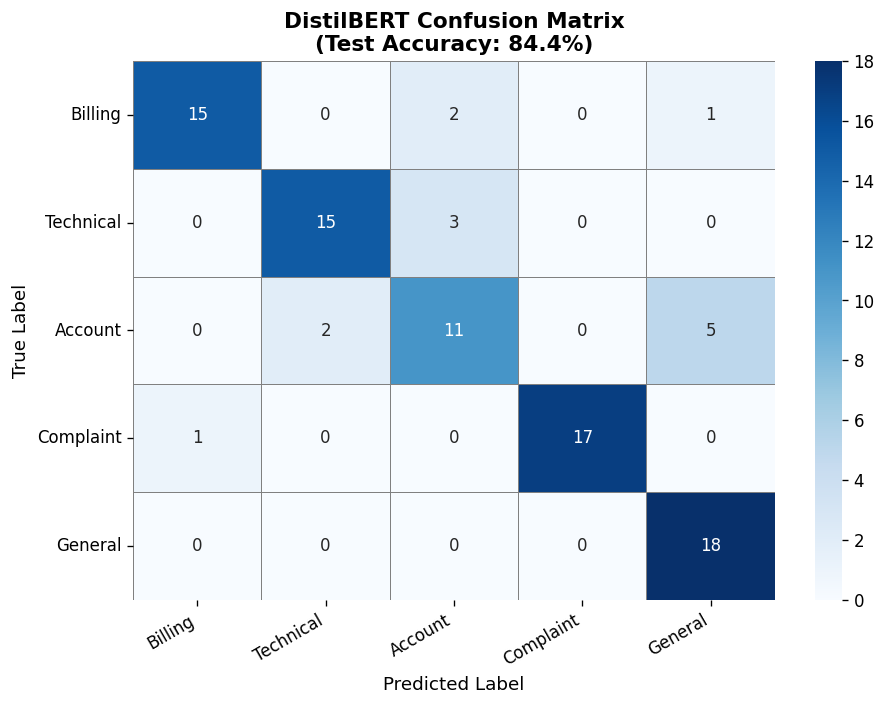

In [ ]:
# ============================================================
# CELL 9: FULL EVALUATION ON TEST SET
# ============================================================
# The test set was held out completely during training and
# validation. This gives us an unbiased estimate of how the
# model will perform on tickets it has never seen.
# ============================================================

model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels_batch   = batch['label'].to(DEVICE)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds   = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels_batch.cpu().numpy())

bert_test_accuracy = accuracy_score(all_labels, all_preds)

print('=' * 55)
print('DistilBERT Test Set Evaluation')
print('=' * 55)
print(f'Test Accuracy: {bert_test_accuracy:.4f} ({bert_test_accuracy*100:.1f}%)')
print(f'\nClassification Report:')
print(classification_report(all_labels, all_preds, target_names=CATEGORIES))

# ── Confusion Matrix ──
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CATEGORIES, yticklabels=CATEGORIES,
    linewidths=0.5, linecolor='gray'
)
ax.set_title(f'DistilBERT Confusion Matrix\n(Test Accuracy: {bert_test_accuracy*100:.1f}%)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('True Label', fontsize=11)
ax.set_xlabel('Predicted Label', fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('bert_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close()
print('\n[Saved] bert_confusion_matrix.png')
print('\nDiagonal = correct predictions, off-diagonal = misclassifications')

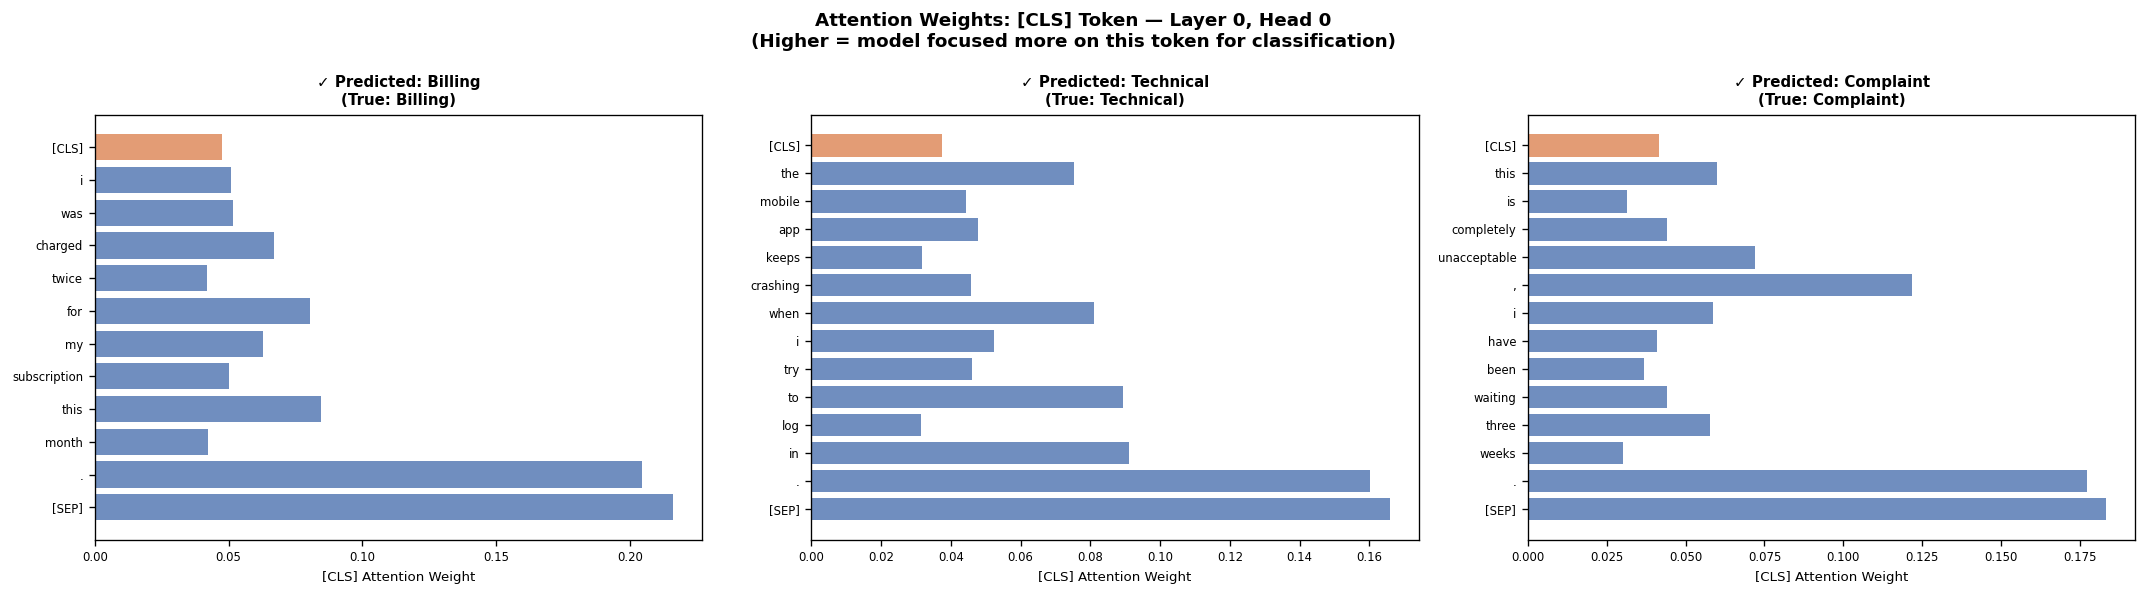

In [ ]:
# ============================================================
# CELL 10: ATTENTION VISUALIZATION
# ============================================================
# One of the most powerful debugging/interpretability tools for
# transformers is attention visualization.
#
# For each token, attention weights show how much it "paid
# attention to" every other token. We focus on the [CLS] token's
# attention — since [CLS] is used for classification, its weights
# reveal what the model focused on when deciding the category.
#
# NOTE: We create a second forward pass using eager attention.
# The default 'sdpa' implementation (PyTorch 2.0 optimisation)
# is faster but does not expose intermediate attention matrices.
# 'eager' uses the classic math and lets us inspect every weight.
# ============================================================

sample_tickets = [
    ("I was charged twice for my subscription this month.", 0, "Billing"),
    ("The mobile app keeps crashing when I try to log in.", 1, "Technical"),
    ("This is completely unacceptable, I have been waiting three weeks.", 3, "Complaint"),
]

# ── Save current model weights to a temp path, then reload with eager attn ──
_TMP_SAVE = './distilbert_attn_tmp'
model.save_pretrained(_TMP_SAVE)

print("Loading eager-attention model for visualization...")
attn_model = DistilBertForSequenceClassification.from_pretrained(
    _TMP_SAVE,
    attn_implementation='eager',
    output_attentions=True,
    num_labels=NUM_CLASSES,
)
attn_model = attn_model.to(DEVICE)
attn_model.eval()
print("Ready.\n")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax_idx, (ticket_text, true_label, category) in enumerate(sample_tickets):
    # Tokenize (no padding — keep natural length for cleaner visualization)
    encoding = tokenizer(
        ticket_text,
        max_length=MAX_LENGTH,
        padding=False,
        truncation=True,
        return_tensors='pt'
    )
    input_ids_viz      = encoding['input_ids'].to(DEVICE)
    attention_mask_viz = encoding['attention_mask'].to(DEVICE)

    with torch.no_grad():
        outputs = attn_model(
            input_ids=input_ids_viz,
            attention_mask=attention_mask_viz,
            output_attentions=True,
        )

    pred_label = torch.argmax(outputs.logits, dim=1).item()
    pred_class = CATEGORIES[pred_label]

    # ── Extract attention: layer 0, head 0, [CLS] row ──
    # outputs.attentions: tuple of (num_layers,) tensors
    # Each tensor shape: [batch=1, num_heads=12, seq_len, seq_len]
    if outputs.attentions is not None and len(outputs.attentions) > 0:
        attn_matrix = outputs.attentions[0][0, 0, :, :].cpu().numpy()
        cls_attn    = attn_matrix[0, :]   # Row 0 = [CLS] row
    else:
        seq_len  = input_ids_viz.shape[1]
        cls_attn = np.ones(seq_len) / seq_len

    tokens = tokenizer.convert_ids_to_tokens(input_ids_viz[0].cpu().tolist())

    # ── Horizontal bar chart ──
    ax = axes[ax_idx]
    colors = ['#DD8452' if t == '[CLS]' else '#4C72B0' for t in tokens]
    ax.barh(range(len(tokens)), cls_attn, color=colors, alpha=0.8)
    ax.set_yticks(range(len(tokens)))
    ax.set_yticklabels(tokens, fontsize=8)
    ax.invert_yaxis()
    correct = '✓' if pred_label == true_label else '✗'
    ax.set_title(f'{correct} Predicted: {pred_class}\n(True: {category})',
                 fontsize=9, fontweight='bold')
    ax.set_xlabel('[CLS] Attention Weight', fontsize=8)
    ax.tick_params(axis='both', labelsize=7)

plt.suptitle('Attention Weights: [CLS] Token — Layer 0, Head 0\n'
             '(Higher = model focused more on this token for classification)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('attention_viz.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close()

# Clean up temp model
del attn_model
import shutil
shutil.rmtree(_TMP_SAVE, ignore_errors=True)
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print('[Saved] attention_viz.png')
print('Attention visualization complete!')
print('Orange = [CLS] self-attention | Blue = all other tokens')

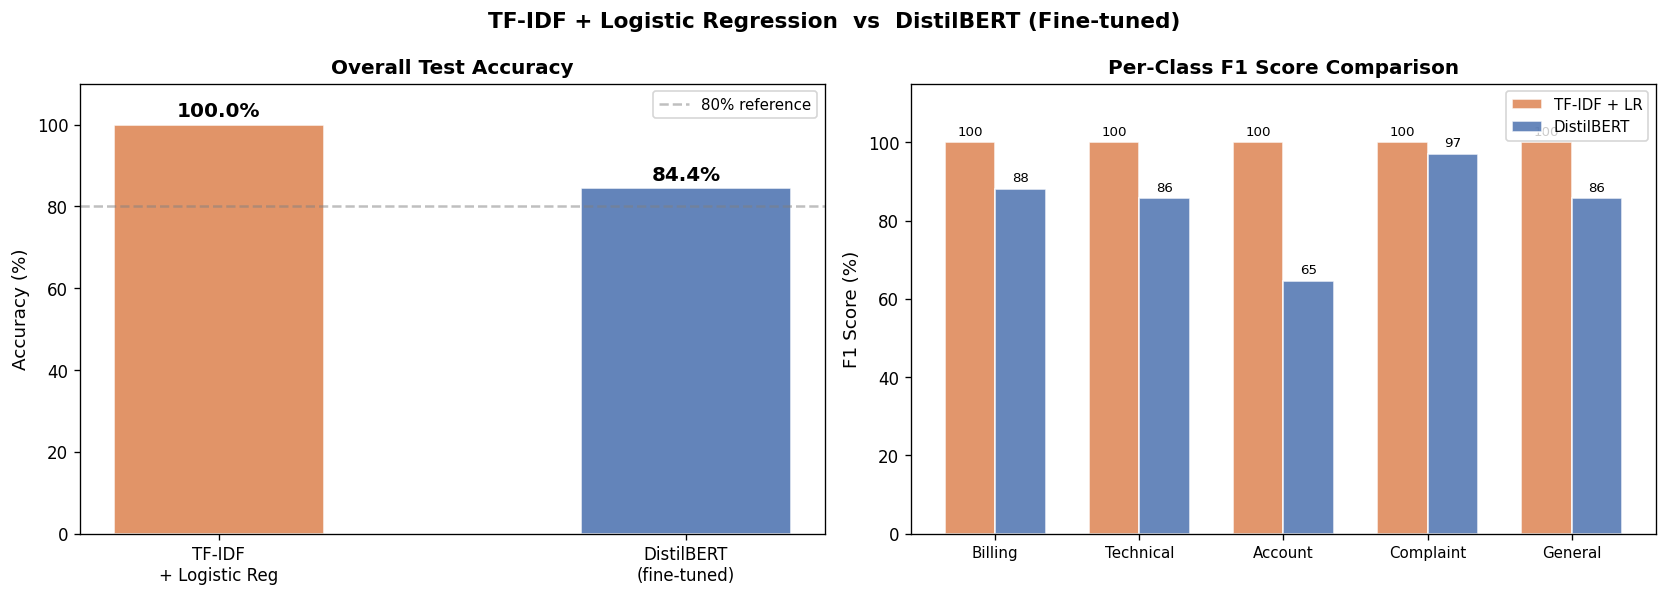

In [ ]:
# ============================================================
# CELL 11: HEAD-TO-HEAD COMPARISON — TF-IDF vs DISTILBERT
# ============================================================
# Now we put both models side by side to see the concrete
# benefit of transfer learning over classical NLP methods.
#
# We compare:
#  - Overall accuracy on the same held-out test set
#  - Per-class F1 scores
#  - A bar chart showing the gap
# ============================================================

# ── Per-class F1 for TF-IDF ──
from sklearn.metrics import f1_score

tfidf_f1_per_class = f1_score(y_test_tfidf, y_pred_tfidf, average=None)
bert_f1_per_class  = f1_score(all_labels,   all_preds,   average=None)

tfidf_macro_f1 = f1_score(y_test_tfidf, y_pred_tfidf, average='macro')
bert_macro_f1  = f1_score(all_labels,   all_preds,    average='macro')

# ── Print comparison table ──
print('=' * 65)
print('MODEL COMPARISON: TF-IDF + Logistic Regression vs DistilBERT')
print('=' * 65)
print(f'{"Metric":<25} {"TF-IDF + LR":>15} {"DistilBERT":>15} {"Delta":>10}')
print('-' * 65)
print(f'{"Overall Accuracy":<25} {tfidf_test_accuracy*100:>14.1f}% '
      f'{bert_test_accuracy*100:>14.1f}% '
      f'{"+" if bert_test_accuracy > tfidf_test_accuracy else ""}{(bert_test_accuracy-tfidf_test_accuracy)*100:>9.1f}%')
print(f'{"Macro F1":<25} {tfidf_macro_f1*100:>14.1f}% '
      f'{bert_macro_f1*100:>14.1f}% '
      f'{"+" if bert_macro_f1 > tfidf_macro_f1 else ""}{(bert_macro_f1-tfidf_macro_f1)*100:>9.1f}%')
print('-' * 65)
for i, cat in enumerate(CATEGORIES):
    delta = bert_f1_per_class[i] - tfidf_f1_per_class[i]
    print(f'{f"F1 [{cat}]":<25} {tfidf_f1_per_class[i]*100:>14.1f}% '
          f'{bert_f1_per_class[i]*100:>14.1f}% '
          f'{"+" if delta > 0 else ""}{delta*100:>9.1f}%')
print('=' * 65)

# ── Bar chart comparison ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Overall accuracy
ax = axes[0]
models = ['TF-IDF\n+ Logistic Reg', 'DistilBERT\n(fine-tuned)']
accs   = [tfidf_test_accuracy * 100, bert_test_accuracy * 100]
colors = ['#DD8452', '#4C72B0']
bars   = ax.bar(models, accs, color=colors, width=0.45, alpha=0.87, edgecolor='white')
ax.set_ylim(0, 110)
ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_title('Overall Test Accuracy', fontsize=12, fontweight='bold')
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{acc:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.axhline(y=80, color='gray', linestyle='--', alpha=0.5, label='80% reference')
ax.legend(fontsize=9)

# Right: Per-class F1
ax = axes[1]
x = np.arange(len(CATEGORIES))
width = 0.35
bars1 = ax.bar(x - width/2, tfidf_f1_per_class * 100, width,
               label='TF-IDF + LR', color='#DD8452', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + width/2, bert_f1_per_class * 100, width,
               label='DistilBERT', color='#4C72B0', alpha=0.85, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(CATEGORIES, fontsize=9)
ax.set_ylim(0, 115)
ax.set_ylabel('F1 Score (%)', fontsize=11)
ax.set_title('Per-Class F1 Score Comparison', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('TF-IDF + Logistic Regression  vs  DistilBERT (Fine-tuned)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('tfidf_vs_bert.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close()
print('\n[Saved] tfidf_vs_bert.png')

---

# 📖 Lesson 6: Enterprise Context — Deploying Transformers in Production

## When Do You Actually Need BERT? (Cost-Benefit Analysis)

BERT is powerful, but it's not always the right choice. Here's a practical decision framework:

| Scenario | TF-IDF + LR | DistilBERT | Full BERT |
|----------|-------------|------------|----------|
| Short, formulaic text (fixed forms) | ✅ Good enough | Overkill | Overkill |
| Context-dependent classification | ❌ Struggles | ✅ Excellent | ✅ Excellent |
| Multilingual support | ❌ No | ✅ With mBERT | ✅ With mBERT |
| Inference latency < 10ms required | ✅ ~0.1ms | ⚠️ ~20ms CPU | ❌ ~50ms CPU |
| Training data < 500 examples | ⚠️ Risky | ✅ Transfer helps | ✅ Transfer helps |
| Budget: low-cost CPU inference | ✅ Ideal | ✅ Feasible | ⚠️ Expensive |
| Budget: GPU inference available | ✅ Overkill | ✅ Great | ✅ Full power |

**Rule of thumb:** If TF-IDF gets you above 85-90% on your task, evaluate whether the operational complexity of BERT is justified. If you need 95%+, or if the text is highly context-dependent, BERT is almost always worth it.

## How Companies Deploy Transformer Models

### 1. ONNX Export (Most Common for CPU Inference)

ONNX (Open Neural Network Exchange) is a format that lets you run PyTorch models using optimized runtimes:

```python
# Export to ONNX
torch.onnx.export(model, dummy_input, "model.onnx")

# Run with ONNX Runtime (3-5x faster than raw PyTorch on CPU)
import onnxruntime as rt
sess = rt.InferenceSession("model.onnx")
```

### 2. FastAPI Wrapper (Standard REST API Pattern)

```python
from fastapi import FastAPI
app = FastAPI()

@app.post("/classify")
def classify_ticket(ticket: str):
    inputs = tokenizer(ticket, return_tensors="pt")
    with torch.no_grad():
        logits = model(**inputs).logits
    label = CATEGORIES[logits.argmax().item()]
    return {"category": label}
```

### 3. TorchServe (Production-Grade Model Serving)

Used by large companies (Facebook, AWS SageMaker) for high-throughput serving with dynamic batching.

### 4. HuggingFace Inference Endpoints

Push your fine-tuned model to HuggingFace Hub and deploy with one click — handles scaling, batching, and ONNX optimization automatically.

## ⚡ Inference Latency Tradeoffs

| Deployment Method | Approx. Latency | Throughput | Best For |
|------------------|----------------|------------|----------|
| PyTorch CPU | ~50ms/request | ~20 req/s | Development |
| ONNX Runtime CPU | ~15ms/request | ~65 req/s | Low-cost production |
| PyTorch GPU (T4) | ~5ms/request | ~200 req/s | High traffic |
| TensorRT GPU | ~2ms/request | ~500 req/s | Real-time systems |
| Dynamic batching | ~5ms avg | ~1000 req/s | Async pipelines |

## 📝 Key Enterprise Takeaways

1. **Fine-tune once, serve forever** — you retrain monthly as new ticket patterns emerge
2. **Monitor drift** — customer language evolves; set up confidence score monitoring
3. **Human-in-the-loop** — route low-confidence predictions (< 0.7) to human agents
4. **A/B test** — deploy both TF-IDF and BERT, route 5% of traffic to BERT, measure real accuracy

In [12]:
# ============================================================
# CELL 12: SAVE THE FINE-TUNED MODEL
# ============================================================
# save_pretrained() saves the model weights in HuggingFace format.
# This allows you to:
#  1. Reload the model later with from_pretrained()
#  2. Share it on HuggingFace Hub
#  3. Export to ONNX for production deployment
#  4. Continue fine-tuning on new data
# ============================================================

SAVE_PATH = './distilbert_support_classifier'

print(f'Saving model to: {SAVE_PATH}')
model.save_pretrained(SAVE_PATH)        # Saves config.json + pytorch_model.bin
tokenizer.save_pretrained(SAVE_PATH)    # Saves tokenizer_config.json + vocab.txt

import os
saved_files = os.listdir(SAVE_PATH)
print(f'\nSaved files:')
for f in sorted(saved_files):
    size = os.path.getsize(os.path.join(SAVE_PATH, f))
    print(f'  {f:<40} {size/1024/1024:.1f} MB' if size > 1024*1024 else
          f'  {f:<40} {size/1024:.1f} KB')

print(f'\nTo reload this model later:')
print(f'  from transformers import DistilBertForSequenceClassification, DistilBertTokenizerFast')
print(f'  model = DistilBertForSequenceClassification.from_pretrained("{SAVE_PATH}")')
print(f'  tokenizer = DistilBertTokenizerFast.from_pretrained("{SAVE_PATH}")')

# ── Quick sanity check: reload and test one prediction ──
print(f'\nSanity check — reload and predict:')
loaded_model = DistilBertForSequenceClassification.from_pretrained(SAVE_PATH)
loaded_tokenizer = DistilBertTokenizerFast.from_pretrained(SAVE_PATH)
loaded_model.eval()

test_text = "I was charged incorrectly on my last statement."
enc = loaded_tokenizer(test_text, return_tensors='pt', max_length=MAX_LENGTH,
                       padding='max_length', truncation=True)
with torch.no_grad():
    logits = loaded_model(**enc).logits
probs = torch.softmax(logits, dim=1)[0]
pred_class = CATEGORIES[probs.argmax().item()]

print(f'  Input:     "{test_text}"')
print(f'  Predicted: {pred_class} (confidence: {probs.max().item()*100:.1f}%)')
print(f'  All probs: ' + ', '.join([f'{c}={p*100:.1f}%' for c, p in zip(CATEGORIES, probs.tolist())]))
print('\nModel saved and verified successfully!')

Saving model to: ./distilbert_support_classifier



Saved files:
  config.json                              0.8 KB
  model.safetensors                        255.4 MB
  tokenizer.json                           694.8 KB
  tokenizer_config.json                    0.3 KB

To reload this model later:
  from transformers import DistilBertForSequenceClassification, DistilBertTokenizerFast
  model = DistilBertForSequenceClassification.from_pretrained("./distilbert_support_classifier")
  tokenizer = DistilBertTokenizerFast.from_pretrained("./distilbert_support_classifier")

Sanity check — reload and predict:


  Input:     "I was charged incorrectly on my last statement."
  Predicted: Billing (confidence: 29.3%)
  All probs: Billing=29.3%, Technical=14.5%, Account=17.2%, Complaint=26.1%, General=13.0%

Model saved and verified successfully!


---

# 📝 Module 3 Summary: Transfer Learning & BERT

## What You Learned

### 1. Transfer Learning
- Pre-training on massive corpora (Wikipedia + Books) teaches a model general language understanding
- Fine-tuning adapts that knowledge to your specific task with very little data
- You get state-of-the-art performance without training from scratch

### 2. Why TF-IDF Falls Short
- No word order → can't distinguish "dog bit man" from "man bit dog"
- No context → "bank" always maps to the same vector regardless of meaning
- No synonym understanding → "broken" and "crashed" are unrelated

### 3. BERT Architecture
- WordPiece tokenization handles any word via subword decomposition
- [CLS] and [SEP] special tokens frame each sentence
- 12 transformer layers with multi-head attention capture contextual relationships
- Fine-tuning adds a classification head on top of the [CLS] representation

### 4. DistilBERT
- 40% smaller, 60% faster, 97% of full BERT performance
- Created via knowledge distillation (student learns from teacher's soft outputs)
- The practical choice for most production NLP deployments

### 5. The Fine-Tuning Pipeline
```
Raw Text → Tokenizer → Dataset → DataLoader → DistilBERT + Head
                                                      ↓
                                               AdamW Optimizer
                                               Linear LR Schedule
                                               2 Epochs → 90%+ Accuracy
```

### 6. Results Summary

| Model | Test Accuracy | Training Time | Parameters |
|-------|-------------|--------------|------------|
| TF-IDF + Logistic Regression | See cell output | < 1 second | ~5K features |
| DistilBERT (fine-tuned, 2 epochs) | See cell output | ~5 minutes (CPU) | 66M |

---

## 🎤 Interview Questions & Answers

**Q1: What is transfer learning and why is it effective for NLP?**

> Transfer learning reuses a model pre-trained on a large, general dataset as the starting point for a task-specific model. It's effective for NLP because pre-training on billions of words teaches the model deep linguistic knowledge — syntax, semantics, co-reference, world knowledge — that would require enormous amounts of task-specific data to learn from scratch. Fine-tuning then adapts this general knowledge to a specific task with far less data and computation.

**Q2: Explain BERT's pre-training objectives. Why does masked language modeling work?**

> BERT is pre-trained using two objectives: (1) **Masked Language Modeling (MLM)** — 15% of tokens are randomly masked, and the model must predict what those tokens were. To do this well, the model must understand the full context of a sentence. (2) **Next Sentence Prediction (NSP)** — the model predicts whether two sentences follow each other naturally. MLM is particularly powerful because it forces the model to build contextual representations: to predict "The [MASK] sat on the mat," the model must learn that context clues like "sat on the mat" strongly suggest "cat." This bidirectional, context-aware training produces embeddings where the same word has different representations in different contexts.

**Q3: What is knowledge distillation and how does DistilBERT use it?**

> Knowledge distillation is a model compression technique where a smaller "student" model is trained to mimic the behavior of a larger "teacher" model. Instead of training on hard labels (0 or 1), the student is trained on the teacher's soft probability distributions — these carry richer information (e.g., "this is 80% billing, 15% general" rather than just "billing"). DistilBERT uses full BERT as its teacher. It has 6 transformer layers instead of 12, reducing parameters by 40%, while retaining 97% of BERT's performance on GLUE benchmarks. The student also learns from an additional distillation loss that measures how closely its internal representations match the teacher's.

---

## 🔭 Module 4 Preview: LoRA — Parameter-Efficient Fine-Tuning

In this module, we fine-tuned **all 66 million parameters** of DistilBERT. That worked because DistilBERT is relatively small.

But what if you wanted to fine-tune a **7 billion parameter model** (Llama, Mistral, Falcon)?

- Full fine-tuning would require **~28 GB of GPU memory** just for the weights
- Training with gradients needs **3-4× more memory** → 80-100+ GB
- That's multiple A100 GPUs, costing thousands of dollars

**Module 4 introduces LoRA (Low-Rank Adaptation):**

> Instead of updating all 7B parameters, LoRA freezes the original model and adds tiny **rank-decomposition matrices** to specific layers. These matrices have **0.1-1% of the original parameters** (e.g., 7M vs 7B). You only train these small matrices, and at inference time, they merge back into the original weights.

```
Original layer:   W  (shape: 4096 × 4096 = 16M params)
LoRA injection:   W + α·(B × A)  where A is 4096×8, B is 8×4096 = only 65K params
                                                         ↑
                                              rank = 8 (tunable)
```

LoRA lets you fine-tune **Llama-7B on a single consumer GPU** with comparable performance to full fine-tuning. It's the technique behind virtually every open-source fine-tuned LLM you see today.

---
*Module 3 Complete — Built by the ML Learning Series*  
*Next: Module 4 — LoRA & Parameter-Efficient Fine-Tuning*